In [1]:
# Install required packages
!pip install transformers torch datasets rouge-score nltk sentencepiece accelerate -q

  Preparing metadata (setup.py) ... done


In [9]:
# Import necessary libraries
import torch
import requests
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    BartForConditionalGeneration, BartTokenizer,
    pipeline
)
from rouge_score import rouge_scorer
import nltk
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [4]:
# Download Pride and Prejudice from Project Gutenberg
url = "https://www.gutenberg.org/files/1342/1342-0.txt"
response = requests.get(url)
text = response.text

print(f"Total characters downloaded: {len(text)}")
print("\nFirst 500 characters:")
print(text[:500])

Total characters downloaded: 743383

First 500 characters:
*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                               


In [5]:
def clean_gutenberg_text(text):

    # Remove header and footer and clean the text
    # Find the start of the actual book content
    start_markers = [
        "*** START OF THE PROJECT GUTENBERG EBOOK",
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "Chapter 1",
        "CHAPTER I"
    ]

    start_index = 0
    for marker in start_markers:
        idx = text.find(marker)
        if idx != -1:
            start_index = idx
            if "START OF" in marker:
                # Move past the marker line
                start_index = text.find('\n', idx) + 1
            break

    # Find the end of the book content
    end_markers = [
        "*** END OF THE PROJECT GUTENBERG EBOOK",
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "End of the Project Gutenberg"
    ]

    end_index = len(text)
    for marker in end_markers:
        idx = text.find(marker)
        if idx != -1:
            end_index = idx
            break

    # Extract the book content
    book_text = text[start_index:end_index]

    # Clean the text
    book_text = re.sub(r'\r\n', '\n', book_text)  # Normalize line endings
    book_text = re.sub(r'\n{3,}', '\n\n', book_text)  # Remove excessive newlines
    book_text = re.sub(r'[ \t]+', ' ', book_text)  # Normalize spaces
    book_text = book_text.strip()

    return book_text

# Clean the text
cleaned_text = clean_gutenberg_text(text)
print(f"\nCleaned text length: {len(cleaned_text)} characters")
print(f"\nFirst 500 characters of cleaned text:")
print(cleaned_text[:500])


Cleaned text length: 721387 characters

First 500 characters of cleaned text:
[Illustration:

 GEORGE ALLEN
 PUBLISHER

 156 CHARING CROSS ROAD
 LONDON

 RUSKIN HOUSE
 ]

 [Illustration:

 _Reading Jane’s Letters._ _Chap 34._
 ]

 PRIDE.
 and
 PREJUDICE

 by
 Jane Austen,

 with a Preface by
 George Saintsbury
 and
 Illustrations by
 Hugh Thomson

 [Illustration: 1894]

 Ruskin 156. Charing
 House. Cross Road.

 London
 George Allen.

 CHISWICK PRESS:--CHARLES WHITTINGHAM AND CO.
 TOOKS COURT, CHANCERY LANE, LONDON.

 [Illustration:

 _To J. Comyns Carr
 in acknowledgment


In [6]:
def extract_chapters(text):
    # Extract indivisual chapter from book
    # Pattern to match chapter headings
    chapter_pattern = r'Chapter \d+|CHAPTER [IVXLCDM]+'

    # Find all chapter positions
    chapters = []
    matches = list(re.finditer(chapter_pattern, text))

    for i, match in enumerate(matches):
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)

        chapter_text = text[start:end].strip()

        # Only include substantial chapters
        if len(chapter_text) > 100:
            chapters.append({
                'chapter_num': i + 1,
                'title': match.group(),
                'text': chapter_text,
                'word_count': len(chapter_text.split())
            })

    return chapters

# Extract chapters
chapters = extract_chapters(cleaned_text)
print(f"\nTotal chapters extracted: {len(chapters)}")
print(f"\nChapter statistics:")
for i, chapter in enumerate(chapters[:5]):
    print(f"Chapter {chapter['chapter_num']}: {chapter['word_count']} words")


Total chapters extracted: 59

Chapter statistics:
Chapter 1: 810 words
Chapter 2: 1720 words
Chapter 3: 1067 words
Chapter 4: 967 words
Chapter 5: 2363 words


In [7]:
# Create a DataFrame
df_chapters = pd.DataFrame(chapters)

print("\nChapter Statistics:")
print(df_chapters[['chapter_num', 'title', 'word_count']].head(10))
print(f"\nAverage chapter length: {df_chapters['word_count'].mean():.0f} words")
print(f"Median chapter length: {df_chapters['word_count'].median():.0f} words")
print(f"Min chapter length: {df_chapters['word_count'].min()} words")
print(f"Max chapter length: {df_chapters['word_count'].max()} words")


Chapter Statistics:
   chapter_num         title  word_count
0            1    CHAPTER II         810
1            2   CHAPTER III        1720
2            3    CHAPTER IV        1067
3            4     CHAPTER V         967
4            5    CHAPTER VI        2363
5            6   CHAPTER VII        2005
6            7  CHAPTER VIII        1940
7            8    CHAPTER IX        1730
8            9     CHAPTER X        2230
9           10    CHAPTER XI        1598

Average chapter length: 2059 words
Median chapter length: 1857 words
Min chapter length: 676 words
Max chapter length: 5193 words


In [10]:
class SummarizationModel:
    """
    SummarizationModel (BART-only version)
    --------------------------------------
    This class loads a BART model and generates summaries using it.
    """

    def __init__(self, model_name, device='cpu'):
        # Store configuration
        self.model_name = model_name
        self.device = device

        # Placeholders for model + tokenizer
        self.model = None
        self.tokenizer = None

        # Load model on initialization
        self.load_model()

    def load_model(self):
        """Load the BART model and tokenizer."""
        print(f"Loading BART model: {self.model_name}...")

        # Load BART tokenizer and model
        self.tokenizer = BartTokenizer.from_pretrained(self.model_name)
        self.model = BartForConditionalGeneration.from_pretrained(self.model_name)

        # Move model to CPU/GPU
        self.model.to(self.device)
        self.model.eval()

        print(f"BART model loaded successfully on {self.device}")

    def summarize(
        self,
        text,
        max_length=150,
        min_length=50,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
        no_repeat_ngram_size=3
    ):
        """
        Generate a summary using BART.

        Parameters:
        - text: The input text to summarize.
        - max_length: Maximum output summary length.
        - min_length: Minimum output summary length.
        - num_beams: Beam search width.
        - length_penalty: Controls summary length.
        - early_stopping: Stop when beams complete.
        - no_repeat_ngram_size: Prevent repeating n-grams.
        """

        # Tokenize and prepare input for BART
        inputs = self.tokenizer(
            text,
            max_length=1024,          # BART max input size
            truncation=True,
            return_tensors="pt"
        ).to(self.device)

        # Generate summary
        with torch.no_grad():
            summary_ids = self.model.generate(
                inputs['input_ids'],
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=early_stopping,
                no_repeat_ngram_size=no_repeat_ngram_size
            )

        # Decode tokens → readable text
        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        return summary


# Initialize BART model
print("Initializing BART model...\n")
models = {
    'BART': SummarizationModel('facebook/bart-large-cnn', device=device),
}

Initializing BART model...

Loading BART model: facebook/bart-large-cnn...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART model loaded successfully on cuda


## 4. Hyperparameter Tuning

We'll test different combinations of hyperparameters to find the best configuration.

In [11]:
# Define hyperparameter configurations to test
hyperparameter_configs = [
    {
        'name': 'Config 1: Balanced',
        'max_length': 150,
        'min_length': 50,
        'num_beams': 4,
        'length_penalty': 2.0,
        'no_repeat_ngram_size': 3
    },
    {
        'name': 'Config 2: Longer Summary',
        'max_length': 200,
        'min_length': 80,
        'num_beams': 4,
        'length_penalty': 2.0,
        'no_repeat_ngram_size': 3
    },
    {
        'name': 'Config 3: More Diverse',
        'max_length': 150,
        'min_length': 50,
        'num_beams': 6,
        'length_penalty': 1.5,
        'no_repeat_ngram_size': 4
    },
    {
        'name': 'Config 4: Concise',
        'max_length': 100,
        'min_length': 30,
        'num_beams': 4,
        'length_penalty': 2.5,
        'no_repeat_ngram_size': 3
    },
    {
        'name': 'Config 5: High Quality',
        'max_length': 150,
        'min_length': 50,
        'num_beams': 8,
        'length_penalty': 2.0,
        'no_repeat_ngram_size': 3
    }
]

print("Hyperparameter Configurations:")
for i, config in enumerate(hyperparameter_configs, 1):
    print(f"\n{config['name']}:")
    for key, value in config.items():
        if key != 'name':
            print(f"  {key}: {value}")

Hyperparameter Configurations:

Config 1: Balanced:
  max_length: 150
  min_length: 50
  num_beams: 4
  length_penalty: 2.0
  no_repeat_ngram_size: 3

Config 2: Longer Summary:
  max_length: 200
  min_length: 80
  num_beams: 4
  length_penalty: 2.0
  no_repeat_ngram_size: 3

Config 3: More Diverse:
  max_length: 150
  min_length: 50
  num_beams: 6
  length_penalty: 1.5
  no_repeat_ngram_size: 4

Config 4: Concise:
  max_length: 100
  min_length: 30
  num_beams: 4
  length_penalty: 2.5
  no_repeat_ngram_size: 3

Config 5: High Quality:
  max_length: 150
  min_length: 50
  num_beams: 8
  length_penalty: 2.0
  no_repeat_ngram_size: 3


## 5. Generate Summaries

Let's generate summaries for a sample of chapters using different configurations.

In [12]:
# Select sample chapters for testing
sample_chapters = chapters[:5]

print(f"Testing on {len(sample_chapters)} chapters")
print("Sample chapters:", [ch['chapter_num'] for ch in sample_chapters])

Testing on 5 chapters
Sample chapters: [1, 2, 3, 4, 5]


In [13]:
# Generate summaries for all configurations
results = []

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Testing {model_name} model")
    print('='*60)

    for config in tqdm(hyperparameter_configs, desc=f"{model_name} Configs"):
        for chapter in sample_chapters:
            # Generate summary
            summary = model.summarize(
                chapter['text'],
                max_length=config['max_length'],
                min_length=config['min_length'],
                num_beams=config['num_beams'],
                length_penalty=config['length_penalty'],
                no_repeat_ngram_size=config['no_repeat_ngram_size']
            )

            results.append({
                'model': model_name,
                'config': config['name'],
                'chapter_num': chapter['chapter_num'],
                'original_text': chapter['text'],
                'summary': summary,
                'original_length': len(chapter['text'].split()),
                'summary_length': len(summary.split()),
                'compression_ratio': len(chapter['text'].split()) / len(summary.split()),
                **{k: v for k, v in config.items() if k != 'name'}
            })

# Create DataFrame
df_results = pd.DataFrame(results)
print(f"\nTotal summaries generated: {len(df_results)}")
print(df_results[['model', 'config', 'chapter_num', 'summary_length', 'compression_ratio']].head(10))


Testing BART model


BART Configs:   0%|          | 0/5 [00:00<?, ?it/s]


Total summaries generated: 25
  model                    config  chapter_num  summary_length  \
0  BART        Config 1: Balanced            1              51   
1  BART        Config 1: Balanced            2              47   
2  BART        Config 1: Balanced            3              52   
3  BART        Config 1: Balanced            4              51   
4  BART        Config 1: Balanced            5              47   
5  BART  Config 2: Longer Summary            1              72   
6  BART  Config 2: Longer Summary            2              72   
7  BART  Config 2: Longer Summary            3              77   
8  BART  Config 2: Longer Summary            4              66   
9  BART  Config 2: Longer Summary            5              83   

   compression_ratio  
0          15.882353  
1          36.595745  
2          20.519231  
3          18.960784  
4          50.276596  
5          11.250000  
6          23.888889  
7          13.857143  
8          14.651515  
9          2

In [15]:
# Display sample summaries
print("\n" + "="*80)
print("SAMPLE SUMMARIES - Chapter 1")
print("="*80)

sample_chapter_num = 1
chapter_results = df_results[df_results['chapter_num'] == sample_chapter_num]

print(f"\nORIGINAL TEXT (First 500 characters):")
print(chapter_results.iloc[0]['original_text'][:500] + "...")
print(f"\nOriginal Length: {chapter_results.iloc[0]['original_length']} words\n")

for idx, row in chapter_results.iterrows():
    print(f"\n{'-'*80}")
    print(f"Model: {row['model']}")
    print(f"Config: {row['config']}")
    print(f"Summary Length: {row['summary_length']} words")
    print(f"Compression Ratio: {row['compression_ratio']:.2f}x")
    print(f"\nSummary:\n{row['summary']}")


SAMPLE SUMMARIES - Chapter 1

ORIGINAL TEXT (First 500 characters):
.

[Illustration]

Mr. Bennet was among the earliest of those who waited on Mr. Bingley. He
had always intended to visit him, though to the last always assuring his
wife that he should not go; and till the evening after the visit was
paid she had no knowledge of it. It was then disclosed in the following
manner. Observing his second daughter employed in trimming a hat, he
suddenly addressed her with,--

“I hope Mr. Bingley will like it, Lizzy.”

“We are not in a way to know _what_ Mr. Bingley li...

Original Length: 810 words


--------------------------------------------------------------------------------
Model: BART
Config: Config 1: Balanced
Summary Length: 51 words
Compression Ratio: 15.88x

Summary:
Lizzy Bennet asked her mother to introduce her father to Mr. Bingley. Her mother said that Mrs. Long had promised to introduce him. Mr. Bennet said that he would take it on himself. He said that a fortnight’s acquain

In [17]:
import nltk
nltk.download('punkt_tab')

def create_extractive_summary(text, num_sentences=5):
    """
    Create a simple extractive summary by selecting first and last sentences,
    and some middle sentences. This serves as our reference summary.
    """
    sentences = nltk.sent_tokenize(text)

    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    # Take first sentence, last sentence, and evenly distributed middle sentences
    selected_sentences = [sentences[0]]  # First sentence

    # Middle sentences
    middle_count = num_sentences - 2
    step = len(sentences) // (middle_count + 1)
    for i in range(1, middle_count + 1):
        idx = min(i * step, len(sentences) - 2)
        selected_sentences.append(sentences[idx])

    selected_sentences.append(sentences[-1])  # Last sentence

    return ' '.join(selected_sentences)

# Create reference summaries
print("Creating reference summaries...")
for idx, row in df_results.iterrows():
    reference = create_extractive_summary(row['original_text'], num_sentences=5)
    df_results.at[idx, 'reference_summary'] = reference

print("Reference summaries created.")
print(f"\nSample reference summary for Chapter 1:")
print(df_results[df_results['chapter_num'] == 1].iloc[0]['reference_summary'])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Creating reference summaries...
Reference summaries created.

Sample reference summary for Chapter 1:
. Have a little
compassion on my nerves. I cannot quite agree with you _there_. But I knew I should
persuade you at last. [Illustration: “I’m the tallest”]

[Illustration:

 “He rode a black horse”
]


In [18]:
def calculate_rouge_scores(predictions, references):
    """
    Calculate ROUGE-1, ROUGE-2, and ROUGE-L scores.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    return {
        'rouge1': {
            'mean': np.mean(rouge1_scores),
            'std': np.std(rouge1_scores),
            'scores': rouge1_scores
        },
        'rouge2': {
            'mean': np.mean(rouge2_scores),
            'std': np.std(rouge2_scores),
            'scores': rouge2_scores
        },
        'rougeL': {
            'mean': np.mean(rougeL_scores),
            'std': np.std(rougeL_scores),
            'scores': rougeL_scores
        }
    }

# Calculate ROUGE scores for each configuration
print("Calculating ROUGE scores...\n")

evaluation_results = []

for model_name in df_results['model'].unique():
    for config_name in df_results['config'].unique():
        subset = df_results[
            (df_results['model'] == model_name) &
            (df_results['config'] == config_name)
        ]

        rouge_scores = calculate_rouge_scores(
            subset['summary'].tolist(),
            subset['reference_summary'].tolist()
        )

        evaluation_results.append({
            'model': model_name,
            'config': config_name,
            'rouge1_mean': rouge_scores['rouge1']['mean'],
            'rouge1_std': rouge_scores['rouge1']['std'],
            'rouge2_mean': rouge_scores['rouge2']['mean'],
            'rouge2_std': rouge_scores['rouge2']['std'],
            'rougeL_mean': rouge_scores['rougeL']['mean'],
            'rougeL_std': rouge_scores['rougeL']['std'],
            'avg_compression_ratio': subset['compression_ratio'].mean(),
            'avg_summary_length': subset['summary_length'].mean()
        })

df_evaluation = pd.DataFrame(evaluation_results)
print("ROUGE Score Evaluation Results:")
print(df_evaluation.to_string(index=False))

Calculating ROUGE scores...

ROUGE Score Evaluation Results:
model                   config  rouge1_mean  rouge1_std  rouge2_mean  rouge2_std  rougeL_mean  rougeL_std  avg_compression_ratio  avg_summary_length
 BART       Config 1: Balanced     0.222677    0.048292     0.006479    0.008330     0.122477    0.017109              28.446942                49.6
 BART Config 2: Longer Summary     0.245619    0.049228     0.024850    0.009919     0.145774    0.032823              18.423485                74.0
 BART   Config 3: More Diverse     0.191931    0.045766     0.006439    0.008263     0.108535    0.023302              29.529895                47.6
 BART        Config 4: Concise     0.195207    0.054699     0.002721    0.005442     0.112118    0.023513              34.706966                41.0
 BART   Config 5: High Quality     0.205314    0.056979     0.009799    0.008412     0.119226    0.033545              27.997632                51.2


## 7. Results Analysis and Visualization

In [19]:
# Find best configuration for each model
print("\n" + "="*80)
print("BEST CONFIGURATIONS BY MODEL")
print("="*80 + "\n")

for model_name in df_evaluation['model'].unique():
    model_results = df_evaluation[df_evaluation['model'] == model_name]
    best_config = model_results.loc[model_results['rouge1_mean'].idxmax()]

    print(f"Model: {model_name}")
    print(f"Best Configuration: {best_config['config']}")
    print(f"  ROUGE-1: {best_config['rouge1_mean']:.4f} (±{best_config['rouge1_std']:.4f})")
    print(f"  ROUGE-2: {best_config['rouge2_mean']:.4f} (±{best_config['rouge2_std']:.4f})")
    print(f"  ROUGE-L: {best_config['rougeL_mean']:.4f} (±{best_config['rougeL_std']:.4f})")
    print(f"  Avg Compression: {best_config['avg_compression_ratio']:.2f}x")
    print(f"  Avg Summary Length: {best_config['avg_summary_length']:.0f} words")
    print()


BEST CONFIGURATIONS BY MODEL

Model: BART
Best Configuration: Config 2: Longer Summary
  ROUGE-1: 0.2456 (±0.0492)
  ROUGE-2: 0.0248 (±0.0099)
  ROUGE-L: 0.1458 (±0.0328)
  Avg Compression: 18.42x
  Avg Summary Length: 74 words



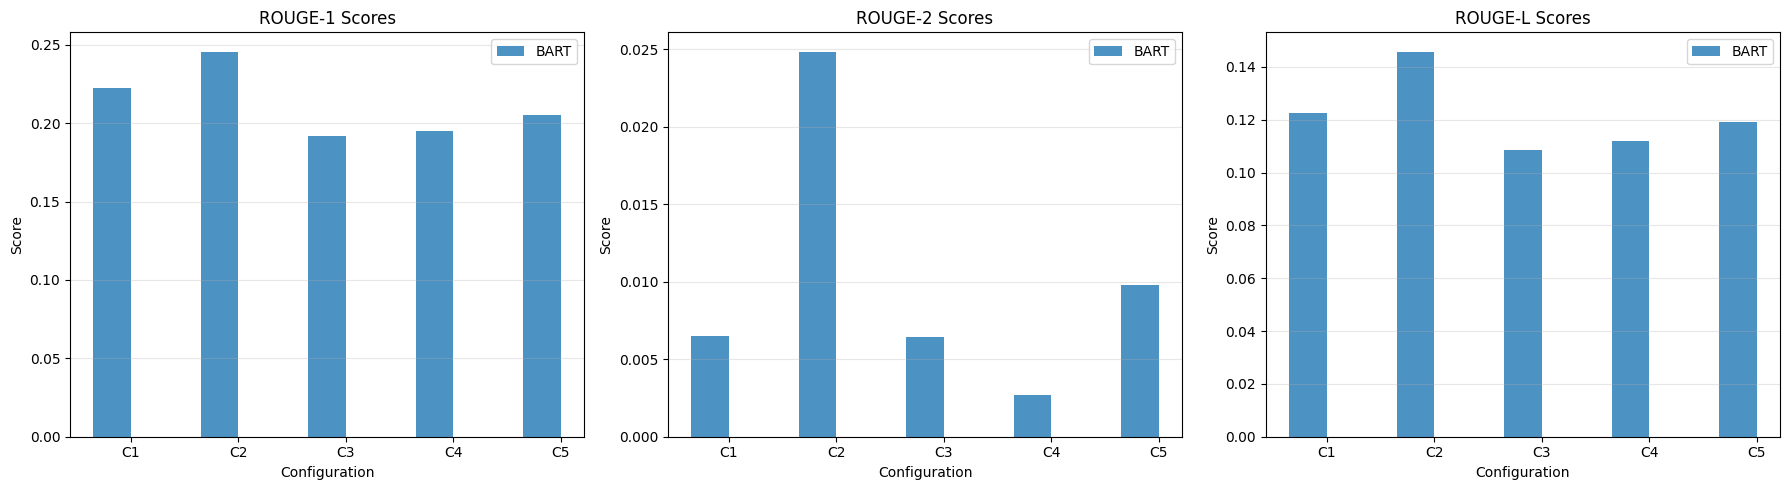

In [20]:
# Visualization 1: ROUGE Scores by Configuration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rouge1_mean', 'rouge2_mean', 'rougeL_mean']
titles = ['ROUGE-1 Scores', 'ROUGE-2 Scores', 'ROUGE-L Scores']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]

    # Plot for each model
    x_pos = np.arange(len(df_evaluation['config'].unique()))
    width = 0.35

    for i, model_name in enumerate(df_evaluation['model'].unique()):
        model_data = df_evaluation[df_evaluation['model'] == model_name]
        values = model_data[metric].values
        ax.bar(x_pos + i * width, values, width,
               label=model_name, alpha=0.8)

    ax.set_xlabel('Configuration')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(x_pos + width / 2)
    ax.set_xticklabels([f'C{i+1}' for i in range(len(x_pos))], rotation=0)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Get best overall configuration
best_overall = df_evaluation.loc[df_evaluation['rouge1_mean'].idxmax()]
best_model_name = best_overall['model']
best_config_name = best_overall['config']

# Get the hyperparameters for best config
best_config_params = [c for c in hyperparameter_configs if c['name'] == best_config_name][0]

print(f"Best Model: {best_model_name}")
print(f"Best Configuration: {best_config_name}")
print(f"\nHyperparameters:")
for key, value in best_config_params.items():
    if key != 'name':
        print(f"  {key}: {value}")
print(f"\nROUGE-1 Score: {best_overall['rouge1_mean']:.4f}")
print(f"ROUGE-2 Score: {best_overall['rouge2_mean']:.4f}")
print(f"ROUGE-L Score: {best_overall['rougeL_mean']:.4f}")

Best Model: BART
Best Configuration: Config 2: Longer Summary

Hyperparameters:
  max_length: 200
  min_length: 80
  num_beams: 4
  length_penalty: 2.0
  no_repeat_ngram_size: 3

ROUGE-1 Score: 0.2456
ROUGE-2 Score: 0.0248
ROUGE-L Score: 0.1458


In [25]:
# Generate summaries for all chapters using best configuration
print(f"\nGenerating summaries for all {len(chapters)} chapters...")

all_chapter_summaries = []
best_model = models[best_model_name]

for chapter in tqdm(chapters, desc="Summarizing chapters"):
    summary = best_model.summarize(
        chapter['text'],
        max_length=best_config_params['max_length'],
        min_length=best_config_params['min_length'],
        num_beams=best_config_params['num_beams'],
        length_penalty=best_config_params['length_penalty'],
        no_repeat_ngram_size=best_config_params['no_repeat_ngram_size']
    )

    all_chapter_summaries.append({
        'chapter_num': chapter['chapter_num'],
        'title': chapter['title'],
        'summary': summary,
        'word_count': len(summary.split())
    })

df_all_summaries = pd.DataFrame(all_chapter_summaries)
print("\nAll chapter summaries generated!")
print(df_all_summaries.head())


Generating summaries for all 59 chapters...


Summarizing chapters:   0%|          | 0/59 [00:00<?, ?it/s]


All chapter summaries generated!
   chapter_num        title  \
0            1   CHAPTER II   
1            2  CHAPTER III   
2            3   CHAPTER IV   
3            4    CHAPTER V   
4            5   CHAPTER VI   

                                             summary  word_count  
0  Lizzy Bennet asked her mother to introduce her...          72  
1  Mr. Bingley was invited to a ball at Netherfie...          72  
2  Jane and Elizabeth Bingley met Mr. Bingley and...          77  
3  Sir William Lucas had been formerly in trade i...          66  
4  Jane Bennet is in love with Bingley. She has k...          83  


In [26]:
# Display sample summaries from different parts of the book
sample_chapters_to_show = [1, 10, 20, 30, 40]

print("\n" + "="*80)
print("SAMPLE CHAPTER SUMMARIES")
print("="*80)

for ch_num in sample_chapters_to_show:
    if ch_num <= len(df_all_summaries):
        summary_row = df_all_summaries[df_all_summaries['chapter_num'] == ch_num].iloc[0]
        print(f"\n{'-'*80}")
        print(f"Chapter {summary_row['chapter_num']}: {summary_row['title']}")
        print(f"Summary ({summary_row['word_count']} words):")
        print(summary_row['summary'])


SAMPLE CHAPTER SUMMARIES

--------------------------------------------------------------------------------
Chapter 1: CHAPTER II
Summary (72 words):
Lizzy Bennet asked her mother to introduce her father to Mr. Bingley. Her mother said that Mrs. Long had promised to introduce him. Mr. Bennet said that he would take it on himself. He said that a fortnight’s acquaintance is certainly very little; one cannot know what a man really is by the end of a night. He added: “I was sure you loved your girls too well topersuade you at last’

--------------------------------------------------------------------------------
Chapter 10: CHAPTER XI
Summary (66 words):
Elizabeth Bennet and her sister Jane were at a dinner party with their brother and sister-in-law. Mr. Darcy was full of joy and warmth when he saw his sister. He sat down by her, and talked scarcely to anyone else in the room. Miss Bennet took up a book, and was as much engaged in watching Mr.Darcy’s progress through his book as in reading

In [27]:
# Create a comprehensive book summary by combining chapter summaries
all_summaries_text = ' '.join(df_all_summaries['summary'].tolist())

print(f"Combined chapter summaries length: {len(all_summaries_text.split())} words")
print("\nGenerating overall book summary...")

# Generate final book summary
book_summary = best_model.summarize(
    all_summaries_text,
    max_length=300,
    min_length=100,
    num_beams=6,
    length_penalty=2.0,
    no_repeat_ngram_size=3
)

print("\n" + "="*80)
print("PRIDE AND PREJUDICE - OVERALL BOOK SUMMARY")
print("="*80)
print(f"\n{book_summary}")
print(f"\n(Summary length: {len(book_summary.split())} words)")

Combined chapter summaries length: 4212 words

Generating overall book summary...

PRIDE AND PREJUDICE - OVERALL BOOK SUMMARY

Lizzy Bennet asked her mother to introduce her father to Mr. Bingley. Her mother said that Mrs. Long had promised to introduce him. Mr. Bennet said that he would take it on himself. Mr Darcy was so popular that he was given a large estate in Derbyshire. Jane and Elizabeth Bingley met Mr. Darcy and his sisters. Catherine and Lydia Bennet lived in Longbourn, a village near Meryton. Their father had been an attorney in the town, and their mother had left her four thousand pounds.

(Summary length: 86 words)


In [28]:
# Save all results to CSV files
df_evaluation.to_csv('evaluation_results.csv', index=False)
df_all_summaries.to_csv('all_chapter_summaries.csv', index=False)
df_results.to_csv('detailed_results.csv', index=False)

# Save book summary
with open('book_summary.txt', 'w') as f:
    f.write("PRIDE AND PREJUDICE - Book Summary\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Configuration: {best_config_name}\n\n")
    f.write(book_summary)

print("Results saved:")
print("  - evaluation_results.csv")
print("  - all_chapter_summaries.csv")
print("  - detailed_results.csv")
print("  - book_summary.txt")

Results saved:
  - evaluation_results.csv
  - all_chapter_summaries.csv
  - detailed_results.csv
  - book_summary.txt
